In [1]:
import os, shutil
import random
import numpy as np
import pandas as pd
import cv2
import skimage
import matplotlib.pyplot as plt
import skimage.segmentation
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
import os
import cv2
import numpy as np
from sklearn.utils import shuffle
from tqdm import tqdm

In [2]:

labels = ['Pneumonia', 'Normal', 'Covid19']
img_size = 224

def get_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        img_files = os.listdir(path)

        print(f"\nLoading {label} ({len(img_files)} images)...")

        # tqdm hiển thị progress bar
        for img in tqdm(img_files):
            try:
                img_path = os.path.join(path, img)
                img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_arr is not None:
                    resized_arr = cv2.resize(img_arr, (img_size, img_size))
                    data.append([resized_arr, class_num])
            except Exception as e:
                print(f"Error reading {img_path}: {e}")
    return data
# Load data (only PNEUMONIA and NORMAL, COVID19 is excluded)
test = get_data("/kaggle/input/test-covid19-pneumonia-normal/Test_COVID19_Pneumonia_Normal/test")

# Trộn ảnh để tránh hiện tượng mô hình học theo thứ tự ảnh
test = shuffle(test, random_state=42)

# Đưa ảnh vào dạng NumPy - Reshape thành (N, 224, 224, 1) → ảnh grayscale 1 kênh
x_test = np.array([i[0] for i in test]).reshape(-1, img_size, img_size, 1)
y_test = np.array([i[1] for i in test])


# Normalize the pixel values to be between 0 and 1
x_test = x_test / 255.0

# Print shapes to verify everything is correct
print("data shape:", x_test.shape)
print("labels shape:", y_test.shape)

# Check class distribution
print("\nClass distribution in test set:")
print(f"PNEUMONIA: {np.sum(y_test == 0)}")
print(f"NORMAL: {np.sum(y_test == 1)}")
print(f"Covid19: {np.sum(y_test == 2)}")




Loading Pneumonia (1485 images)...


100%|██████████| 1485/1485 [00:23<00:00, 63.68it/s]



Loading Normal (1905 images)...


100%|██████████| 1905/1905 [00:30<00:00, 63.04it/s]



Loading Covid19 (630 images)...


100%|██████████| 630/630 [00:10<00:00, 61.69it/s]


data shape: (4020, 224, 224, 1)
labels shape: (4020,)

Class distribution in test set:
PNEUMONIA: 1485
NORMAL: 1905
Covid19: 630


# Vgg16

In [3]:
from tensorflow.keras.models import load_model

model = load_model("/kaggle/input/thanhtrung-cvck/best_model.h5")


2025-12-06 14:02:57.119618: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765029777.309747      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765029777.361568      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

I0000 00:00:1765029792.569974      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [4]:
from sklearn.metrics import accuracy_score

y_prob = model.predict(x_test)

y_pred = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")


I0000 00:00:1765029800.454230      60 service.cc:148] XLA service 0x79947804bc10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765029800.454851      60 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765029800.611670      60 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/126 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step 

I0000 00:00:1765029808.513569      60 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


126/126 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step
Accuracy: 0.9694 (96.94%)


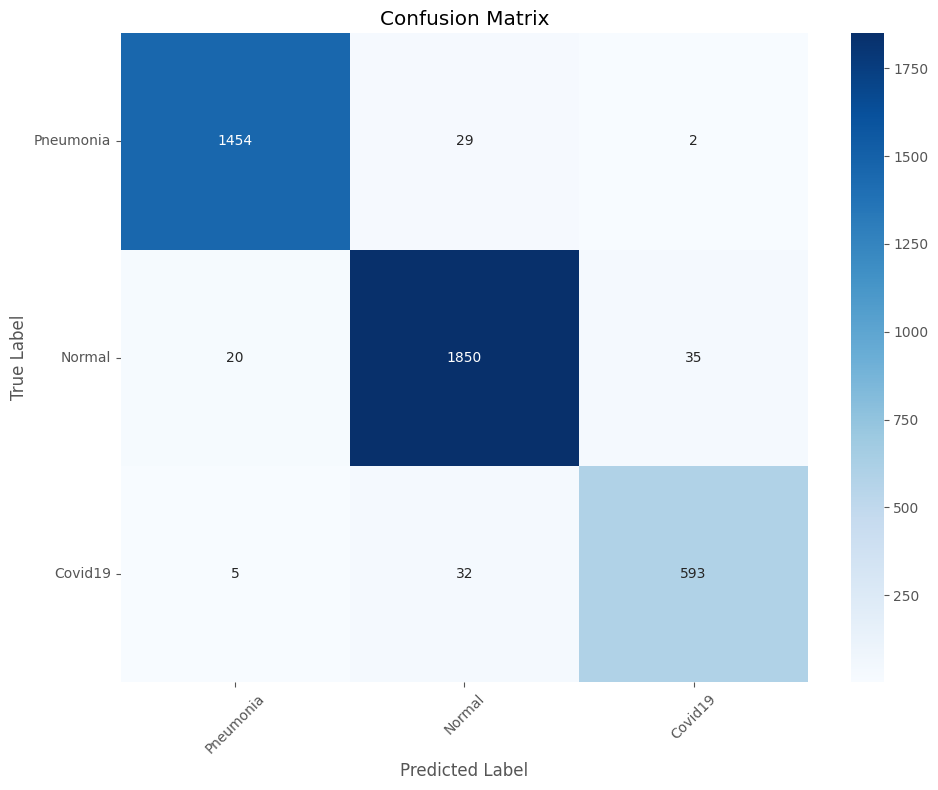

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, class_names):
    """Vẽ confusion matrix với heatmap"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return cm

cm = plot_confusion_matrix(y_test, y_pred, labels)

# ResNet

In [6]:
from tensorflow.keras.models import load_model

model = load_model("/kaggle/input/tvtrung-ckcv/best_model.h5")


In [7]:
from sklearn.metrics import accuracy_score

y_prob = model.predict(x_test)

y_pred = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")


126/126 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step
Accuracy: 0.9756 (97.56%)


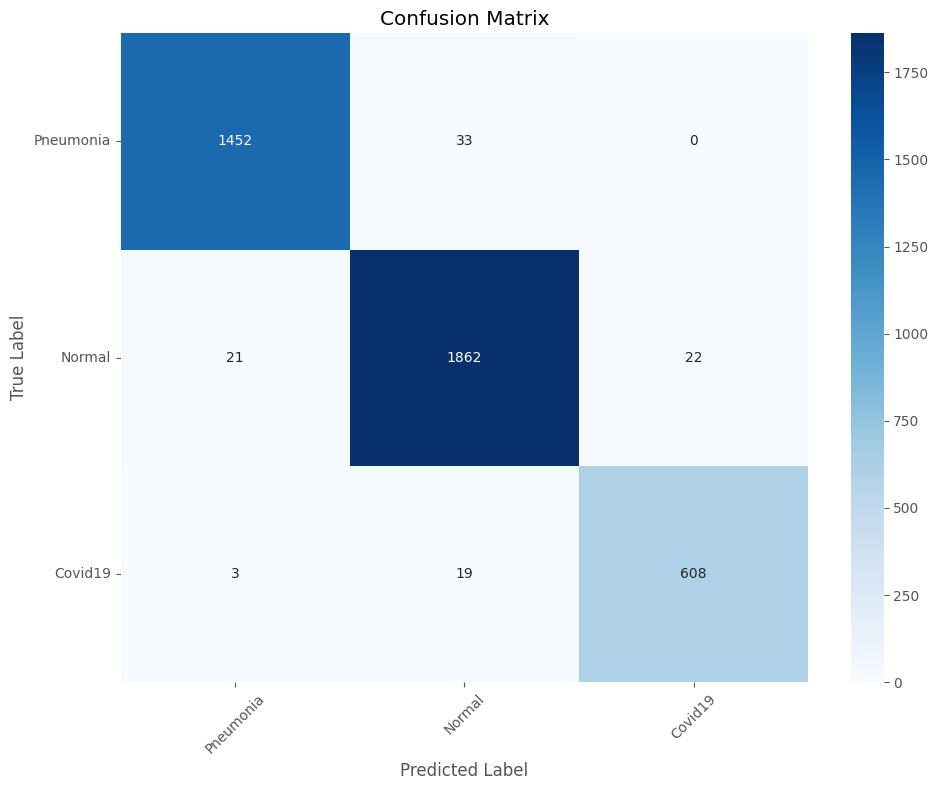

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, class_names):
    """Vẽ confusion matrix với heatmap"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return cm

cm = plot_confusion_matrix(y_test, y_pred, labels)